In [1]:
import jax.numpy as jnp
from differometor.setups import voyager
from dfbench.problems import ConstrainedVoyagerProblem
from dfbench.algorithms import AdamGD
from dfbench import Objective
from dfbench.core.utils import inverse_sigmoid_bounding
from differometor.utils import sigmoid_bounding
from differometor.simulate import simulate
from differometor.utils import calculate_sensitivities, calculate_powers
import jax
import matplotlib.pyplot as plt
from jax import config
import jax.random as jr

config.update("jax_enable_x64", True)

Matplotlib is building the font cache; this may take a moment.


In [2]:
S, component_property_pairs = voyager()

# Extract bounded parameter values from the Voyager setup S,
# using the same optimization pairs and bounds that VoyagerProblem uses
vp = ConstrainedVoyagerProblem()

voyager_params = []
for component_name, property_name in vp.optimization_pairs:
    if "_" not in component_name:
        value = S.nodes[component_name]["properties"][property_name]
    else:
        value = S.edges[component_name]["properties"][property_name]
    voyager_params.append(value)

# voyager_params[i] corresponds to vp.optimization_pairs[i]
voyager_params = jnp.array(voyager_params)


print(f"Number of parameters: {len(voyager_params)}")
print(f"Bounded params (first 5): {voyager_params[:5]}")

Number of parameters: 48
Bounded params (first 5): [153.           0.           0.95099975   0.           0.4999975 ]


In [3]:
# Sanity check: evaluate the objective with the Voyager params
# Loss should be ~0 since these are the target params
obj = Objective(vp, unbounded=False, max_evals=20000, max_time=300, verbose=1)
loss = obj.value(voyager_params)
print(f"Loss at Voyager params: {loss}")
print("(Should be ~0 since these are the target parameters)")

Loss at Voyager params: -6.503472650899659e-13
(Should be ~0 since these are the target parameters)


### Explore Surface Around Voyager Parameters

In [ ]:
# Decompose the loss at the Voyager params to see what's happening
q_results = simulate(**{**vp._q_arrays, "optimized_parameters": voyager_params})
ampl_results = simulate(**{**vp._ampl_arrays, "optimized_parameters": voyager_params})
freq_results = simulate(**{**vp._freq_arrays, "optimized_parameters": voyager_params})
results = [
    (*q_results, *vp._q_metadata),
    (*ampl_results, *vp._ampl_metadata),
    (*freq_results, *vp._freq_metadata),
]

sensitivities = calculate_sensitivities(
    results, vp._sensitivity_function, vp._frequencies, homodyne=True
)
powers = calculate_powers(q_results[0], *vp._q_metadata)

sensitivity_loss, penalty, violations = vp._calculate_loss(
    sensitivities, vp._target_sensitivities, powers
)

print(f"Sensitivity loss: {sensitivity_loss}")
print(f"Penalty (raw):    {penalty}")
print(f"Penalty (scaled): {penalty / (1 + penalty)}")
print(f"Total loss:       {sensitivity_loss + penalty / (1 + penalty)}")
print(f"\nViolations: {violations}")
print(f"Max violation:    {jnp.max(violations)}")

# Now check the gradient magnitude and direction
grad_fn = jax.grad(vp.objective_function)
grads = grad_fn(voyager_params)
print(f"\nGradient norm:    {jnp.linalg.norm(grads):.6e}")
print(f"Max |grad|:       {jnp.max(jnp.abs(grads)):.6e}")
print(f"Grad (first 5):   {grads[:5]}")

# Show which parameters have the largest gradients
top_indices = jnp.argsort(jnp.abs(grads))[-10:]
print("\nTop 10 parameters by gradient magnitude:")
for idx in reversed(top_indices):
    name = vp.optimization_pairs[int(idx)]
    print(
        f"  {name}: grad={grads[int(idx)]:.6e}, value={voyager_params[int(idx)]:.6f}, bounds=[{vp.bounds[0, int(idx)]}, {vp.bounds[1, int(idx)]}]"
    )

Sensitivity loss: -6.258485257931589e-16
Penalty (raw):    0.0
Penalty (scaled): 0.0
Total loss:       -6.258485257931589e-16

Violations: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max violation:    0.0

Gradient norm:    6.079720e+03
Max |grad|:       4.256295e+03
Grad (first 5):   [-0.00139114  0.00165207 -0.01195981 -0.06430357 -0.73981146]

Top 10 parameters by gradient magnitude:
  ('etmy', 'reflectivity'): grad=-4.256295e+03, value=0.999985, bounds=[0.0, 1.0]
  ('etmx', 'reflectivity'): grad=-4.249409e+03, value=0.999985, bounds=[0.0, 1.0]
  ('fm2', 'reflectivity'): grad=-8.684730e+02, value=0.999985, bounds=[0.0, 1.0]
  ('itmy', 'reflectivity'): grad=-9.905100e+01, value=0.998000, bounds=[0.0, 1.0]
  ('itmx', 'reflectivity'): grad=8.542099e+01, value=0.998000, bounds=[0.0, 1.0]
  ('itmy', 'tuning'): grad=-6.607537e+01, value=0.000000, bounds=[-180.0, 180.0]
  ('etmy', 'tuning'): grad=6.599831e+01, value=0

In [ ]:
# 1D sweep along each parameter axis from the Voyager point
# For each parameter, evaluate loss at small perturbations while holding others fixed
obj_fn = vp.objective_function
n_params = len(voyager_params)
n_steps = 50  # points per side (total 2*n_steps + 1 per parameter)

# Sweep a small fraction of each parameter's range
sweep_fraction = 0.001  # 0.1% of range in each direction

results = {}
for idx in range(n_params):
    name = vp.optimization_pairs[idx]
    param_range = vp.bounds[1, idx] - vp.bounds[0, idx]
    center = voyager_params[idx]
    delta = sweep_fraction * param_range

    # Sweep points, clipped to bounds
    offsets = jnp.linspace(-delta, delta, 2 * n_steps + 1)
    values = jnp.clip(center + offsets, vp.bounds[0, idx], vp.bounds[1, idx])

    losses = []
    for val in values:
        test_params = voyager_params.at[idx].set(val)
        l = obj_fn(test_params)
        losses.append(float(l))

    losses = jnp.array(losses)
    min_loss = jnp.min(losses)
    min_idx = jnp.argmin(losses)
    min_val = float(values[min_idx])

    results[idx] = {
        "name": name,
        "center": float(center),
        "values": values,
        "losses": losses,
        "min_loss": float(min_loss),
        "min_val": min_val,
    }

# Print summary: which parameters have loss < 0 somewhere?
print("Parameters where loss < 0 is achievable with single-parameter perturbation:")
print("=" * 80)
negative_params = []
for idx in range(n_params):
    r = results[idx]
    if r["min_loss"] < -1e-10:
        negative_params.append(idx)
        print(
            f"  {r['name']}: min_loss={r['min_loss']:.6e} at value={r['min_val']:.6f} (Voyager={r['center']:.6f})"
        )

if not negative_params:
    print("  NONE — no single-parameter perturbation achieves loss < 0")

print(f"All parameters sorted by minimum achievable loss:")
print("-" * 80)
sorted_indices = sorted(range(n_params), key=lambda i: results[i]["min_loss"])
for idx in sorted_indices[:15]:  # show top 15
    r = results[idx]
    print(
        f"  {r['name']}: min_loss={r['min_loss']:.6e}, Voyager={r['center']:.6f}, best_at={r['min_val']:.6f}"
    )

Parameters where loss < 0 is achievable with single-parameter perturbation:
  ('l0', 'power'): min_loss=-2.770940e-04 at value=153.199990 (Voyager=153.000000)
  ('l0', 'phase'): min_loss=-5.171467e-04 at value=-0.360000 (Voyager=0.000000)
  ('prm', 'reflectivity'): min_loss=-1.534059e-06 at value=0.951260 (Voyager=0.951000)
  ('prm', 'tuning'): min_loss=-1.043072e-03 at value=0.036000 (Voyager=0.000000)
  ('srm', 'reflectivity'): min_loss=-3.132175e-04 at value=0.953000 (Voyager=0.954000)
  ('sq', 'angle'): min_loss=-1.354142e-03 at value=0.360000 (Voyager=0.000000)
  ('fm1', 'reflectivity'): min_loss=-1.529799e-04 at value=0.999020 (Voyager=0.999000)
  ('fm2', 'reflectivity'): min_loss=-1.419373e-02 at value=1.000000 (Voyager=0.999985)
  ('bhbs', 'tuning'): min_loss=-8.907507e-04 at value=0.309600 (Voyager=0.000000)
  ('lo', 'phase'): min_loss=-8.650072e-04 at value=-0.360000 (Voyager=0.000000)
  ('bssus', 'mass'): min_loss=-7.869565e-10 at value=48.434051 (Voyager=48.634041)
  ('itmy

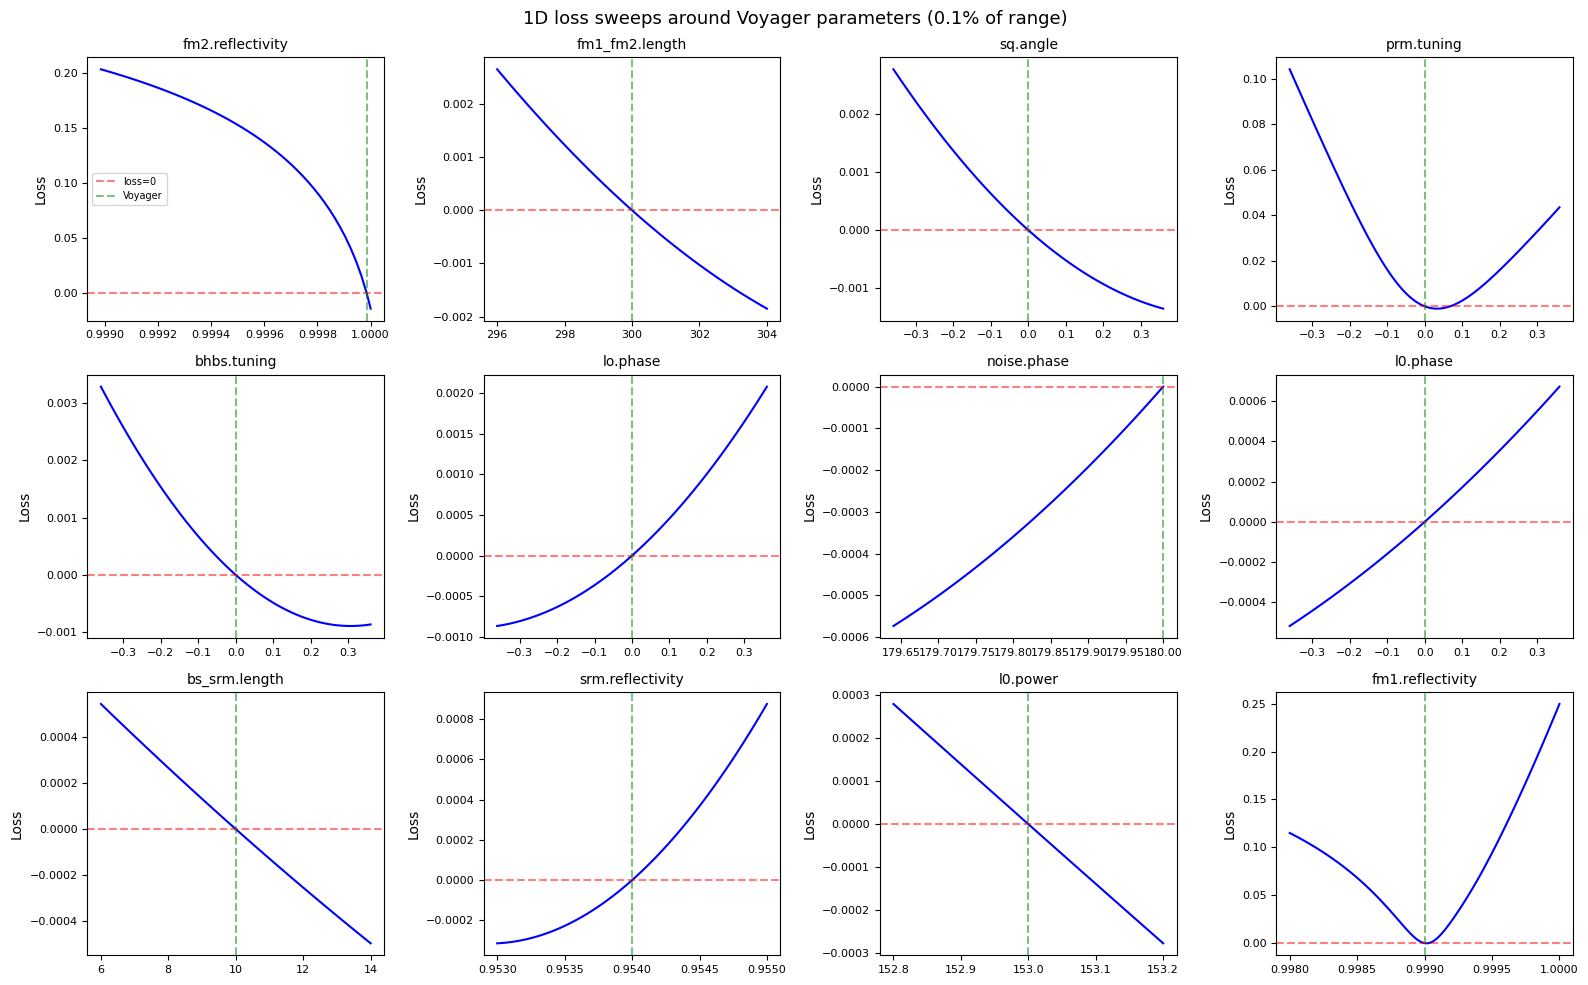

In [6]:
# Plot the 1D loss sweeps for the 12 most sensitive parameters
sorted_indices = sorted(range(n_params), key=lambda i: results[i]["min_loss"])
plot_indices = sorted_indices[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for ax_idx, param_idx in enumerate(plot_indices):
    r = results[param_idx]
    ax = axes[ax_idx]
    ax.plot(r["values"], r["losses"], "b-", linewidth=1.5)
    ax.axhline(y=0, color="r", linestyle="--", alpha=0.5, label="loss=0")
    ax.axvline(x=r["center"], color="g", linestyle="--", alpha=0.5, label="Voyager")
    comp, prop = r["name"]
    ax.set_title(f"{comp}.{prop}", fontsize=10)
    ax.set_ylabel("Loss")
    ax.tick_params(labelsize=8)
    if ax_idx == 0:
        ax.legend(fontsize=7)

fig.suptitle("1D loss sweeps around Voyager parameters (0.1% of range)", fontsize=13)
plt.tight_layout()
plt.show()

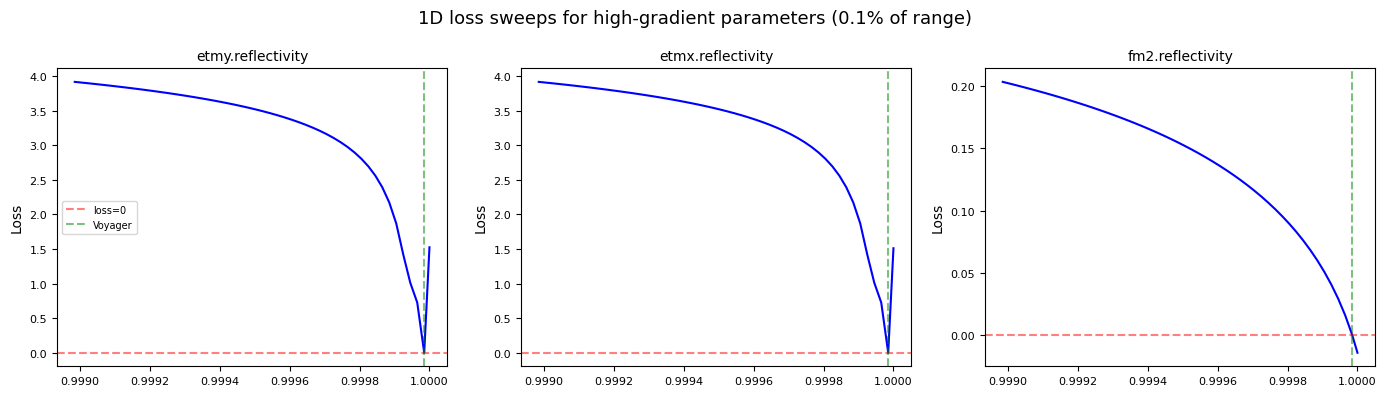

In [7]:
# Plot 1D loss sweeps for the three parameters with largest gradients:
# etmy.reflectivity, etmx.reflectivity, fm2.reflectivity
target_names = [
    ("etmy", "reflectivity"),
    ("etmx", "reflectivity"),
    ("fm2", "reflectivity"),
]
target_indices = [
    idx for idx in range(n_params) if results[idx]["name"] in target_names
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, param_idx in enumerate(target_indices):
    r = results[param_idx]
    ax = axes[ax_idx]
    ax.plot(r["values"], r["losses"], "b-", linewidth=1.5)
    ax.axhline(y=0, color="r", linestyle="--", alpha=0.5, label="loss=0")
    ax.axvline(x=r["center"], color="g", linestyle="--", alpha=0.5, label="Voyager")
    comp, prop = r["name"]
    ax.set_title(f"{comp}.{prop}", fontsize=10)
    ax.set_ylabel("Loss")
    ax.tick_params(labelsize=8)
    if ax_idx == 0:
        ax.legend(fontsize=7)

fig.suptitle("1D loss sweeps for high-gradient parameters (0.1% of range)", fontsize=13)
plt.tight_layout()
plt.show()

### Hessian Exploration

In [4]:
obj_fn = vp.objective_function
obj_grad = jax.jit(jax.grad(obj_fn))
obj_hessian = jax.jit(jax.hessian(obj_fn))

In [19]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import SymLogNorm


def plot_hessian(hess, labels, name, title_suffix="", save=False):
    """Plot Hessian analysis: linear, symlog, and eigendecomposition.

    Args:
        hess: Hessian matrix (n x n).
        labels: List of parameter labels.
        name: String prefix for saved PDF filenames.
        title_suffix: Optional string appended to plot titles.
    """
    title_tag = f" ({title_suffix})" if title_suffix else ""

    # 1. Linear scale
    vmax = max(abs(hess.min()), abs(hess.max()))
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.matshow(hess, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    fig.colorbar(
        im,
        ax=ax,
        shrink=0.8,
        label="$\\partial^2 L / \\partial \\theta_i \\partial \\theta_j$",
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f"Hessian{title_tag}")
    plt.tight_layout()
    if save:
        plt.savefig(f"{name}_hessian.pdf")
    plt.show()

    # 2. sign * log1p scale (adapts to any range automatically)
    hess_log = jnp.sign(hess) * jnp.log1p(jnp.abs(hess))
    vmax_log = max(abs(hess_log.min()), abs(hess_log.max()))
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.matshow(hess_log, cmap="RdBu_r", vmin=-vmax_log, vmax=vmax_log)
    fig.colorbar(
        im,
        ax=ax,
        shrink=0.8,
        label="$\\mathrm{sgn}(H_{ij}) \\cdot \\log(1 + |H_{ij}|)$",
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f"Hessian{title_tag} (log scale)")
    plt.tight_layout()
    if save:
        plt.savefig(f"{name}_hessian_log.pdf")
    plt.show()

    # 3. Eigendecomposition
    D, U = jnp.linalg.eigh(hess)
    n = len(D)

    fig, (ax_u, ax_d) = plt.subplots(
        2,
        1,
        figsize=(14, 12),
        gridspec_kw={"height_ratios": [4, 1]},
        sharex=True,
    )

    # Eigenvectors: values in [-1, 1]
    umax = max(abs(U.min()), abs(U.max()))
    im = ax_u.imshow(
        U,
        cmap="RdBu_r",
        norm=SymLogNorm(linthresh=1e-2, vmin=-umax, vmax=umax),
        aspect="auto",
        extent=[-0.5, n - 0.5, n - 0.5, -0.5],
        interpolation="nearest",
    )

    divider = make_axes_locatable(ax_u)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    fig.colorbar(im, cax=cax, label="Eigenvector component")
    ax_u.set_yticks(range(len(labels)))
    ax_u.set_yticklabels(labels, fontsize=7)
    ax_u.set_ylabel("Parameter")
    ax_u.set_title(f"Eigenvectors (U) and eigenvalues (D){title_tag}")
    ax_u.tick_params(bottom=False, labelbottom=False)

    # Eigenvalues: raw values with symlog y-scale
    colors = ["tab:red" if d > 0 else "tab:blue" for d in D]
    ax_d.bar(range(n), D, color=colors, width=0.8)
    ax_d.set_yscale("symlog", linthresh=1e-6)
    ax_d.set_ylabel("Eigenvalue")
    ax_d.set_xlabel("Eigenvector index")
    ax_d.axhline(0, color="k", linewidth=0.5)
    ax_d.set_xlim(-0.5, n - 0.5)

    divider_d = make_axes_locatable(ax_d)
    cax_d = divider_d.append_axes("right", size="2%", pad=0.1)
    cax_d.set_visible(False)

    plt.tight_layout()
    if save:
        plt.savefig(f"{name}_hessian_eigendecomp.pdf")
    plt.show()

    # Print summary
    n_neg = int((D < 0).sum())
    n_zero = int((jnp.abs(D) < 1e-6).sum())
    n_pos = int((D > 0).sum())
    print(
        f"Eigenvalue summary: {n_neg} negative, {n_zero} near-zero (<1e-6), {n_pos} positive"
    )
    print(f"Range: [{float(D.min()):.4e}, {float(D.max()):.4e}]")
    print(f"Sorted Eigvals: {jnp.sort(D)}")
    print(f"Condition number: {jnp.linalg.cond(hess):.4e}")

    return D, U

In [20]:
lower, upper = vp.bounds[0], vp.bounds[1]
rand_points = lower + (upper - lower) * jr.uniform(jr.PRNGKey(42), (3, 48))

In [7]:
voyager_hess = obj_hessian(voyager_params).block_until_ready()
rand_zero_hess = obj_hessian(rand_points[0]).block_until_ready()
rand_one_hess = obj_hessian(rand_points[1]).block_until_ready()
rand_two_hess = obj_hessian(rand_points[2]).block_until_ready()

In [21]:
print(f"Objective value at Voyager params: {obj.value(voyager_params):.6e}")
print(f"Objective value at rand_0 params: {obj.value(rand_points[0]):.6e}")
print(f"Objective value at rand_1 params: {obj.value(rand_points[1]):.6e}")
print(f"Objective value at rand_2 params: {obj.value(rand_points[2]):.6e}")

Objective value at Voyager params: -6.503473e-13
Objective value at rand_0 params: 8.370776e+00
Objective value at rand_1 params: 8.162059e+00
Objective value at rand_2 params: 9.982314e+00


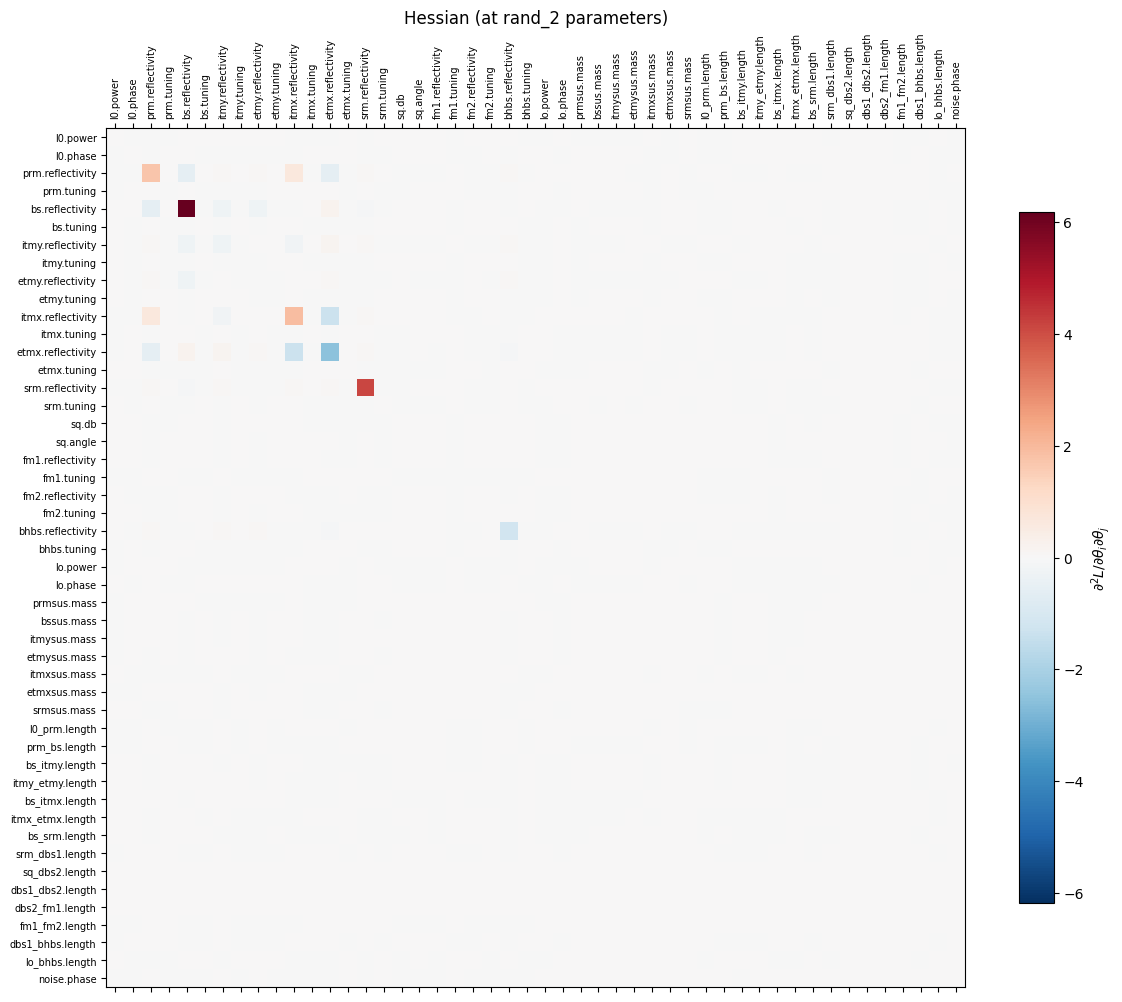

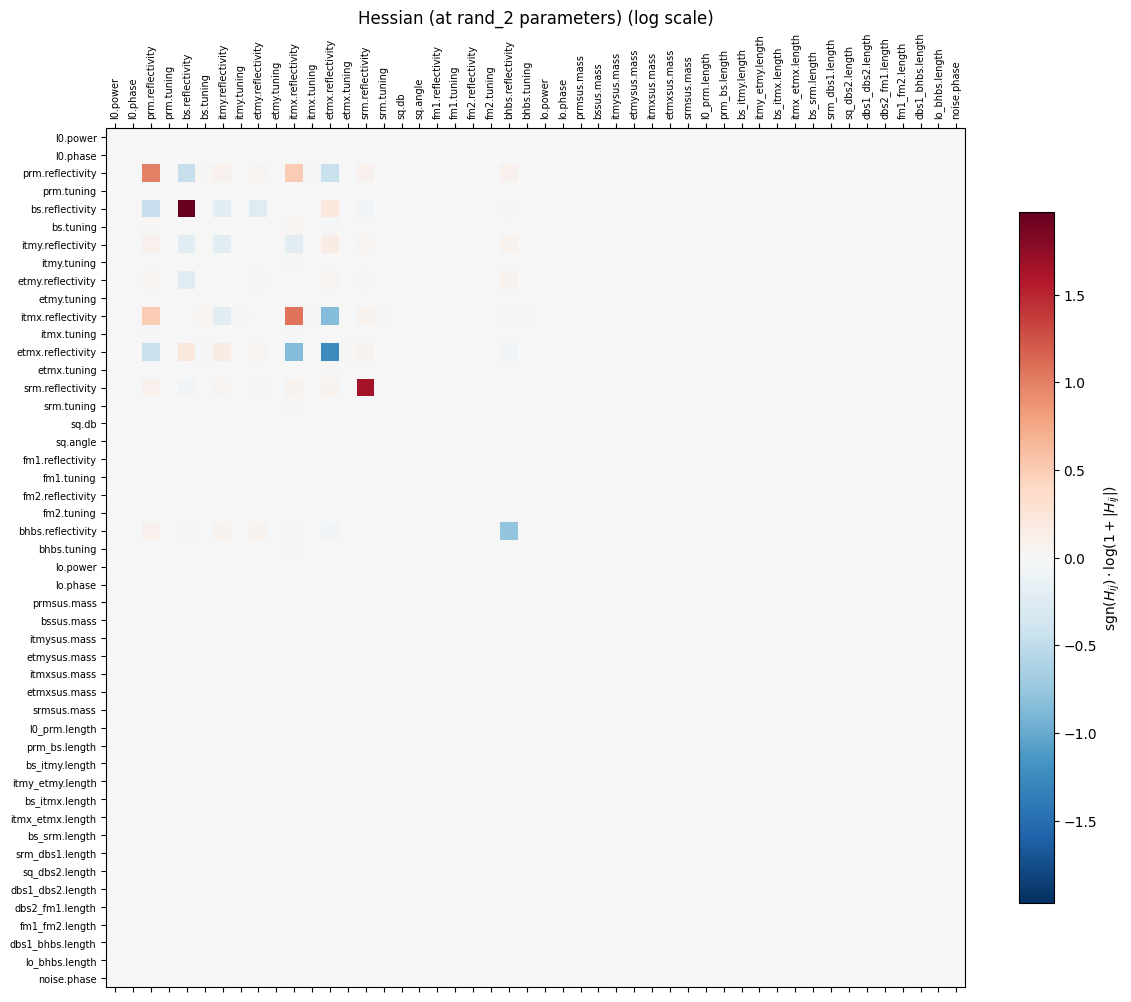

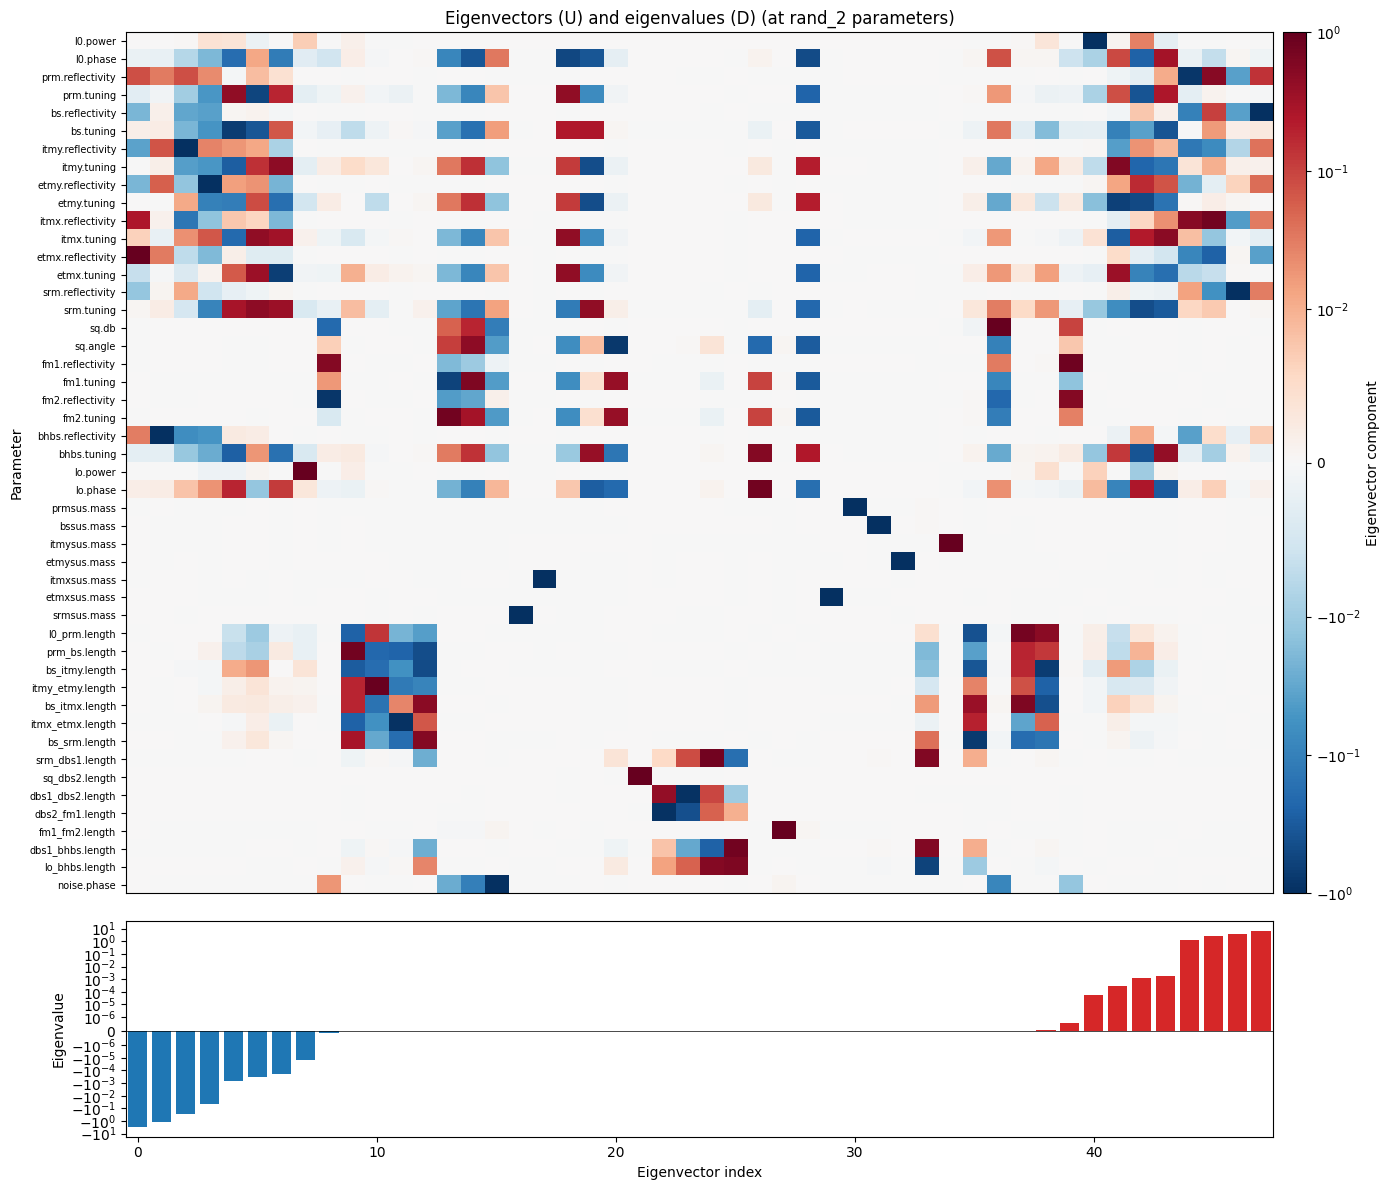

Eigenvalue summary: 21 negative, 32 near-zero (<1e-6), 27 positive
Range: [-2.9465e+00, 6.2991e+00]
Sorted Eigvals: [-2.94653253e+00 -1.18276590e+00 -2.86590069e-01 -4.84773939e-02
 -6.90500216e-04 -3.06990794e-04 -1.95314637e-04 -1.51953662e-05
 -1.64891466e-07 -1.84544589e-08 -1.01550000e-08 -2.63141211e-09
 -1.34978821e-09 -4.63374296e-10 -1.55314991e-10 -1.54694993e-11
 -1.10609420e-11 -2.73517233e-12 -1.34004969e-15 -1.49558514e-16
 -1.05042310e-20  1.27227068e-33  8.86449142e-27  4.88904619e-26
  4.45934548e-25  5.58083165e-25  1.26217279e-19  1.27862134e-16
  2.48880711e-16  2.02190777e-15  1.36348169e-12  1.63516495e-12
  2.16107703e-12  4.17447846e-12  1.82248765e-11  2.02882152e-09
  2.91847174e-09  3.58740774e-08  1.11265554e-07  6.01458610e-07
  5.64960888e-05  3.09240483e-04  1.20631941e-03  1.73413186e-03
  1.16840074e+00  2.81248916e+00  4.14761558e+00  6.29907466e+00]
Condition number: 3.0669e+33


In [25]:
labels = [f"{c}.{p}" for c, p in vp.optimization_pairs]
D, U = plot_hessian(
    rand_two_hess,
    labels,
    name="rand_2",
    title_suffix="at rand_2 parameters",
    save=True,
)

### Newton optimisation

In [79]:
import time
import numpy as np

lower, upper = vp.bounds[0], vp.bounds[1]
init_params = voyager_params.copy()

# JIT-compiled functions
obj_fn = jax.jit(vp.objective_function)
obj_val_grad = jax.jit(jax.value_and_grad(vp.objective_function))
obj_hessian = jax.jit(jax.hessian(vp.objective_function))

eval_count = 0
loss_history = []
t0 = time.time()


def projected_newton_line_search(
    x0, max_iter=10, alpha_init=1.0, alpha_min=1e-16, c=1e-4, rho=0.5
):
    """Newton's method with backtracking line search and bound projection.

    At each iteration:
    1. Identify free variables (not at bounds with gradient pointing outward)
    2. Solve Newton system in the free subspace
    3. Backtracking line search with Armijo condition, projecting onto bounds
    """
    global eval_count
    x = jnp.array(x0, dtype=jnp.float64)

    for iteration in range(max_iter):
        loss, g = obj_val_grad(x)
        eval_count += 1
        loss_history.append(float(loss))
        elapsed = time.time() - t0

        grad_norm = float(jnp.linalg.norm(g))
        print(
            f"  iter {iteration:4d} | loss: {float(loss):.6e} | "
            f"|grad|: {grad_norm:.2e} | {elapsed:.1f}s"
        )

        if grad_norm < 1e-12:
            print("  Converged: gradient norm below tolerance")
            break

        # Identify free variables: not at a bound with gradient pushing outward
        at_lower = jnp.abs(x - lower) < 1e-15
        at_upper = jnp.abs(x - upper) < 1e-15
        clamped = (at_lower & (g > 0)) | (at_upper & (g < 0))
        free = ~clamped

        n_free = int(free.sum())
        if n_free == 0:
            print("  Converged: all variables at bounds (KKT satisfied)")
            break

        # Compute Hessian
        H = obj_hessian(x)

        # Extract free subspace
        free_idx = jnp.where(free)[0]
        H_free = H[jnp.ix_(free_idx, free_idx)]
        g_free = g[free_idx]

        # Solve Newton system in free subspace: H_free @ d_free = -g_free
        # Use regularisation if H is singular/indefinite
        try:
            d_free = jnp.linalg.solve(H_free, -g_free)
        except Exception:
            # Fall back to gradient descent if solve fails
            d_free = -g_free

        # Check if Newton direction is a descent direction
        directional_deriv = float(g_free @ d_free)
        if directional_deriv > 0:
            # Newton direction is ascending — use negative gradient instead
            print("Newton is ascending, switching to negative gradient direction")
            d_free = -g_free
            directional_deriv = float(g_free @ d_free)

        # Build full step direction
        d = jnp.zeros_like(x)
        d = d.at[free_idx].set(d_free)

        # Backtracking line search with Armijo condition and bound projection
        alpha = alpha_init
        while alpha > alpha_min:
            x_new = jnp.clip(x + alpha * d, lower, upper)
            loss_new = obj_fn(x_new)
            eval_count += 1
            loss_history.append(float(loss_new))

            # Armijo condition: sufficient decrease
            actual_step = x_new - x
            predicted_decrease = float(g @ actual_step)
            if float(loss_new) <= float(loss) + c * predicted_decrease:
                print(f"Alpha used: {alpha:.2e}")
                break
            alpha *= rho
        else:
            print(f"  Line search failed at iter {iteration} (alpha={alpha:.2e})")
            break

        x = x_new
        print(
            f"         alpha: {alpha:.2e} | free: {n_free}/{len(x)} | "
            f"step norm: {float(jnp.linalg.norm(actual_step)):.2e}"
        )

    return x


print(f"Initial loss: {float(obj_fn(init_params)):.6e}")
eval_count = 0  # reset after warmup call
loss_history = []
print(f"Parameters: {len(init_params)}")
print()

newton_best_params = projected_newton_line_search(init_params)

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s")
print(f"Final loss:  {float(obj_fn(newton_best_params)):.6e}")
print(f"Evaluations: {eval_count}")

# Show which parameters changed most
param_range = upper - lower
diffs = newton_best_params - init_params
rel_diffs = diffs / param_range
top_changed = jnp.argsort(jnp.abs(rel_diffs))[-10:]
print(f"\nTop 10 parameters by relative change:")
for idx in reversed(top_changed):
    idx = int(idx)
    name = vp.optimization_pairs[idx]
    print(
        f"  {name}: {float(init_params[idx]):.6f} -> {float(newton_best_params[idx]):.6f} "
        f"(rel: {float(rel_diffs[idx]):.6e})"
    )

Initial loss: -6.503473e-13
Parameters: 48

  iter    0 | loss: -6.503463e-13 | |grad|: 6.08e+03 | 5.3s


KeyboardInterrupt: 

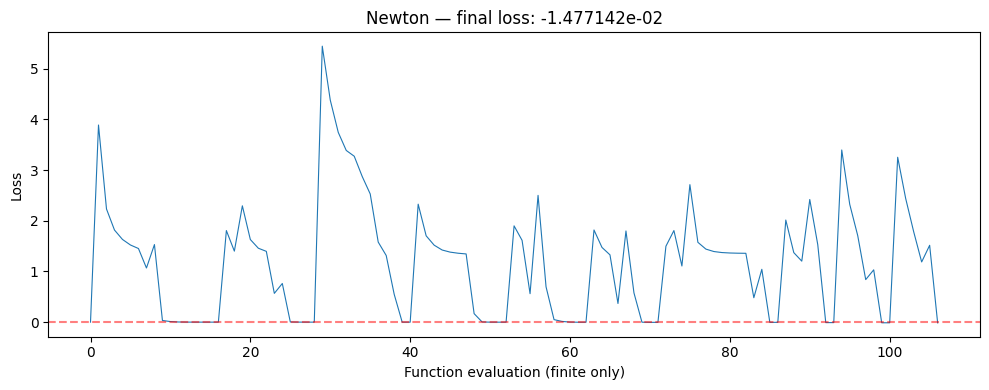

In [49]:
# Plot loss curve
fig, ax = plt.subplots(figsize=(10, 4))
plot_losses = [l for l in loss_history if l < 1e9]
ax.plot(plot_losses, linewidth=0.8)
ax.axhline(y=0, color="r", linestyle="--", alpha=0.5)
ax.set_xlabel("Function evaluation (finite only)")
ax.set_ylabel("Loss")
ax.set_title(f"Newton — final loss: {float(obj_fn(newton_best_params)):.6e}")
plt.tight_layout()
plt.show()

In [50]:
newton_best_params

Array([ 1.81937598e+02, -7.83976374e+01,  9.42230451e-01,  4.90325489e-01,
        4.99273264e-01,  6.36509466e+01,  9.97999540e-01, -5.90526024e-03,
        9.99980830e-01, -5.60847965e-03,  9.97996828e-01,  1.01288532e-02,
        9.99980879e-01,  1.03579130e-02,  9.47202574e-01,  8.99995491e+01,
        1.00000000e+01, -7.51515883e+01,  9.98592486e-01,  7.91542385e-01,
        9.99997531e-01,  7.71091554e-01,  4.30768602e-01,  1.80000000e+02,
        1.17049476e-02,  1.80000000e+02,  1.84040582e+02,  8.30475495e+01,
        1.99951836e+02,  2.00000000e+02,  2.00000000e+02,  2.00000000e+02,
        1.36754629e-02,  4.00000000e+03,  4.00000000e+03,  4.10330278e+01,
        3.99130774e+03,  4.10298216e+01,  3.99686204e+03,  1.00000000e+00,
        4.00000000e+03,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        3.95629114e+02,  4.00000000e+03,  4.00000000e+03,  1.79797136e+02],      dtype=float64)

In [ ]:
voyager_params

Array([ 1.53000000e+02,  0.00000000e+00,  9.50999755e-01,  0.00000000e+00,
        4.99997500e-01,  6.36396103e+01,  9.97999990e-01,  0.00000000e+00,
        9.99985000e-01,  0.00000000e+00,  9.97999990e-01,  0.00000000e+00,
        9.99985000e-01,  0.00000000e+00,  9.53999770e-01,  9.00000000e+01,
        1.00000000e+01,  0.00000000e+00,  9.98999995e-01,  0.00000000e+00,
        9.99985000e-01, -1.40000000e-02,  4.99997500e-01,  1.00000000e-07,
        1.00000000e-02,  0.00000000e+00,  2.92438030e+01,  4.86340409e+01,
        2.00000000e+02,  2.00000000e+02,  2.00000000e+02,  2.00000000e+02,
        5.00000000e+01,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        4.00000000e+03,  1.00000000e+00,  4.00000000e+03,  1.00000000e+01,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+01,  1.00000000e+00,
        3.00000000e+02,  1.00000000e+00,  1.00000000e+01,  1.80000000e+02],      dtype=float64)

In [57]:
newton_best_params[8]

Array(0.99998083, dtype=float64)

In [ ]:
voyager_params[8]

Array(0.999985, dtype=float64)

In [55]:
vp.optimization_pairs[8]

('etmy', 'reflectivity')

In [54]:
vp.optimization_pairs

[('l0', 'power'),
 ('l0', 'phase'),
 ('prm', 'reflectivity'),
 ('prm', 'tuning'),
 ('bs', 'reflectivity'),
 ('bs', 'tuning'),
 ('itmy', 'reflectivity'),
 ('itmy', 'tuning'),
 ('etmy', 'reflectivity'),
 ('etmy', 'tuning'),
 ('itmx', 'reflectivity'),
 ('itmx', 'tuning'),
 ('etmx', 'reflectivity'),
 ('etmx', 'tuning'),
 ('srm', 'reflectivity'),
 ('srm', 'tuning'),
 ('sq', 'db'),
 ('sq', 'angle'),
 ('fm1', 'reflectivity'),
 ('fm1', 'tuning'),
 ('fm2', 'reflectivity'),
 ('fm2', 'tuning'),
 ('bhbs', 'reflectivity'),
 ('bhbs', 'tuning'),
 ('lo', 'power'),
 ('lo', 'phase'),
 ('prmsus', 'mass'),
 ('bssus', 'mass'),
 ('itmysus', 'mass'),
 ('etmysus', 'mass'),
 ('itmxsus', 'mass'),
 ('etmxsus', 'mass'),
 ('srmsus', 'mass'),
 ('l0_prm', 'length'),
 ('prm_bs', 'length'),
 ('bs_itmy', 'length'),
 ('itmy_etmy', 'length'),
 ('bs_itmx', 'length'),
 ('itmx_etmx', 'length'),
 ('bs_srm', 'length'),
 ('srm_dbs1', 'length'),
 ('sq_dbs2', 'length'),
 ('dbs1_dbs2', 'length'),
 ('dbs2_fm1', 'length'),
 ('fm1_f